In [1]:
from pathlib import Path
import re

import numpy as np
import matplotlib.pyplot as plt
import torch
from scipy.io import loadmat
from scipy.signal import butter, filtfilt, find_peaks

import pywt
import heartpy as hp
from tqdm import tqdm

# A novel ternary pattern-based automatic psychiatric disorders classification using ECG signals

### OST: https://www.youtube.com/watch?v=uNMvABJFWHo

### Исследование: https://pmc.ncbi.nlm.nih.gov/articles/PMC10881455/

### Датасет: https://www.kaggle.com/datasets/buraktaci/Psychiatry-ECG

In [2]:
mat = loadmat(Path.cwd() / 'DATASETS' / 'Psychiatry ECG' / 'Bipolar' / '1_bi (4).mat')
print(mat.keys())

print(mat['sinyal'])

dict_keys(['__header__', '__version__', '__globals__', 'label', 'sinyal'])
[[  7.8   3.1  -4.7 ...  -6.6 -13.9 -11.1]
 [  7.6   3.2  -4.4 ...  -6.4 -13.8 -11. ]
 [  6.8   2.9  -3.9 ...  -6.4 -13.7 -10.9]
 ...
 [  9.5   5.1  -4.4 ...  -3.6 -10.5  -7.8]
 [  8.5   4.7  -3.8 ...  -3.7 -10.7  -8. ]
 [  8.2   4.6  -3.6 ...  -3.8 -10.9  -8.2]]


### Класс-обёртка для нашего датасета

Оригинальный код см. в Psychiatry_ECG.py

In [3]:
def extract_number(filename):
    match = re.search(r'\((\d+)\)', str(filename)) # Напр.: supah_cool_file (4).mat
    if match:
        return int(match.group(1)) # Возвращаем найденное число как целое число
    return float('inf') # Если числа нет, ставим "бесконечность", чтобы такие файлы были в конце


class ECGDataset(torch.utils.data.Dataset):
    def __init__(self, path):
        self.path = path
        self.classes = [f.name for f in self.path.iterdir()]

        self.samples = { cls:
            sorted((self.path / cls).iterdir(), key=extract_number) for cls in self.classes
        }
        self.pinned_disorder = None

    # Что такое k??? Типа сколько у нас файлов в этом сэмпле?
    # def get_k(self, cls): 
    #     if cls in ['Bipolar', 'Schizophrenia']:
    #         return 13
    #     elif cls == 'Depression':
    #         return 11

    def set_disorder(self, disorder):
        assert disorder in list(self.samples.keys())
        self.pinned_disorder = disorder

    def __getitem__(self, idx):
        # Получаем сигнал одного конкретного пика;
        # Изначально тут получался какой-то диапаон пиков, но...
        # Почему 11? Почему 13? Чо то K??? Сложна нипанятна!!!11
        data_raw = loadmat(self.samples[self.pinned_disorder][idx])['sinyal']

        # k = self.get_k(self.pinned_disorder)
        # idx_range = [i for i in range(idx*k, idx*k+k)]
        # data_raw = loadmat(self.samples[self.pinned_disorder][idx_range[0]])['sinyal']
        # for i in range(1, len(idx_range)):
        #     signal = loadmat(self.samples[self.pinned_disorder][idx_range[i]])['sinyal']
        #     data_raw = np.append(data_raw, signal, axis=0)

        # Теперь разобъём этот сэмпл пика на отдельные каналы ЭКГ --
        # согласно исследованию, порядок каналов в датасете стандартный
        data_res = dict()
        for ch_idx, ch_label in enumerate([
            'Lead I', 'Lead II', 'Lead III',
            'Lead aVR', 'Lead aVF', 'Lead aVL',
            'Lead v1', 'Lead v2', 'Lead v3',
            'Lead v4', 'Lead v5', 'Lead v6'
        ]):
            data_ch = data_raw[:, ch_idx]
            data_res[ch_label] = data_ch

        return data_res
    
    def __len__(self):
        # k = self.get_k(self.pinned_disorder)
        # return len(list((self.path / self.pinned_disorder).iterdir())) // k
        return len(list((self.path / self.pinned_disorder).iterdir()))
    
    def visualize(self, start, end):
        for i in range(start, end+1):
            sample = self.__getitem__(i)
            labels = list(sample.keys())

            for j in range(4*3):
                plt.subplot(4, 3, j+1)
                plt.plot(sample[labels[j]], label=f'№{i} - {labels[j]}')
                plt.grid()
                plt.legend()

        plt.show()

In [4]:
dataset = ECGDataset(Path.cwd() / 'DATASETS' / 'Psychiatry ECG')

dataset

In [5]:
dataset.set_disorder('Bipolar')

dataset.classes

['Depression', 'Schizophrenia', 'Bipolar']

In [6]:
sample = dataset[6]
labels = list(sample.keys())

sample

{'Lead I': array([12.2, 12.4, 13.3, 13.5, 13.2, 13.2, 13.2, 13. , 13.1, 13.7, 14.2,
        14.1, 14. , 14.2, 14.1, 13.8, 13.9, 14.3, 14.5, 14.6, 14.7, 14.7,
        14.1, 13.4, 13.4, 13.6, 13.5, 13.6, 13.6, 12.8, 11.7, 11.3, 11.5,
        11.6, 11.7, 11.8, 11.7, 11.1, 10.8, 10.6, 10.3,  9.9,  9.5,  9.6,
         9.5,  9.2,  9.2,  9.4,  9. ,  8.2,  8.1,  8.3,  8. ,  7.9,  7.5,
         7.1,  7.6,  8.1,  7.7,  7.5,  8. ,  8.3,  8.3,  8.6,  8.9,  8.6,
         7.5,  6.7,  6.8,  7. ,  7.4,  7.6,  7.9,  8.6,  8.3,  7.4,  7.1,
         6.9,  7.1,  7.5,  7.6,  7.9,  8.4,  8.3,  7.5,  6.8,  7.1,  7.5,
         7.9,  8.3,  8.1,  7.4,  7.3,  7.5,  7.6,  7.7,  7.5,  7.5,  7.8,
         7.7,  7.3,  7.2,  7.6,  8. ,  7.9,  7.6,  7.6,  7.6,  7.9,  7.8,
         7.6,  7.5,  7.6,  7.7,  7.4,  7.2,  7.3,  7.4,  7.4,  7.5,  7.3,
         7.2,  7.6,  7.8,  7.8,  7.4,  7.2,  7.2,  6.8,  6.8,  7.2,  7.5,
         8. ,  8.4,  8.5,  8.5,  7.9,  7. ,  6.5,  6.2,  6.4,  6.4,  6.7,
         7.1,  7.1,  7.4,  7

Визуализация данных поканально

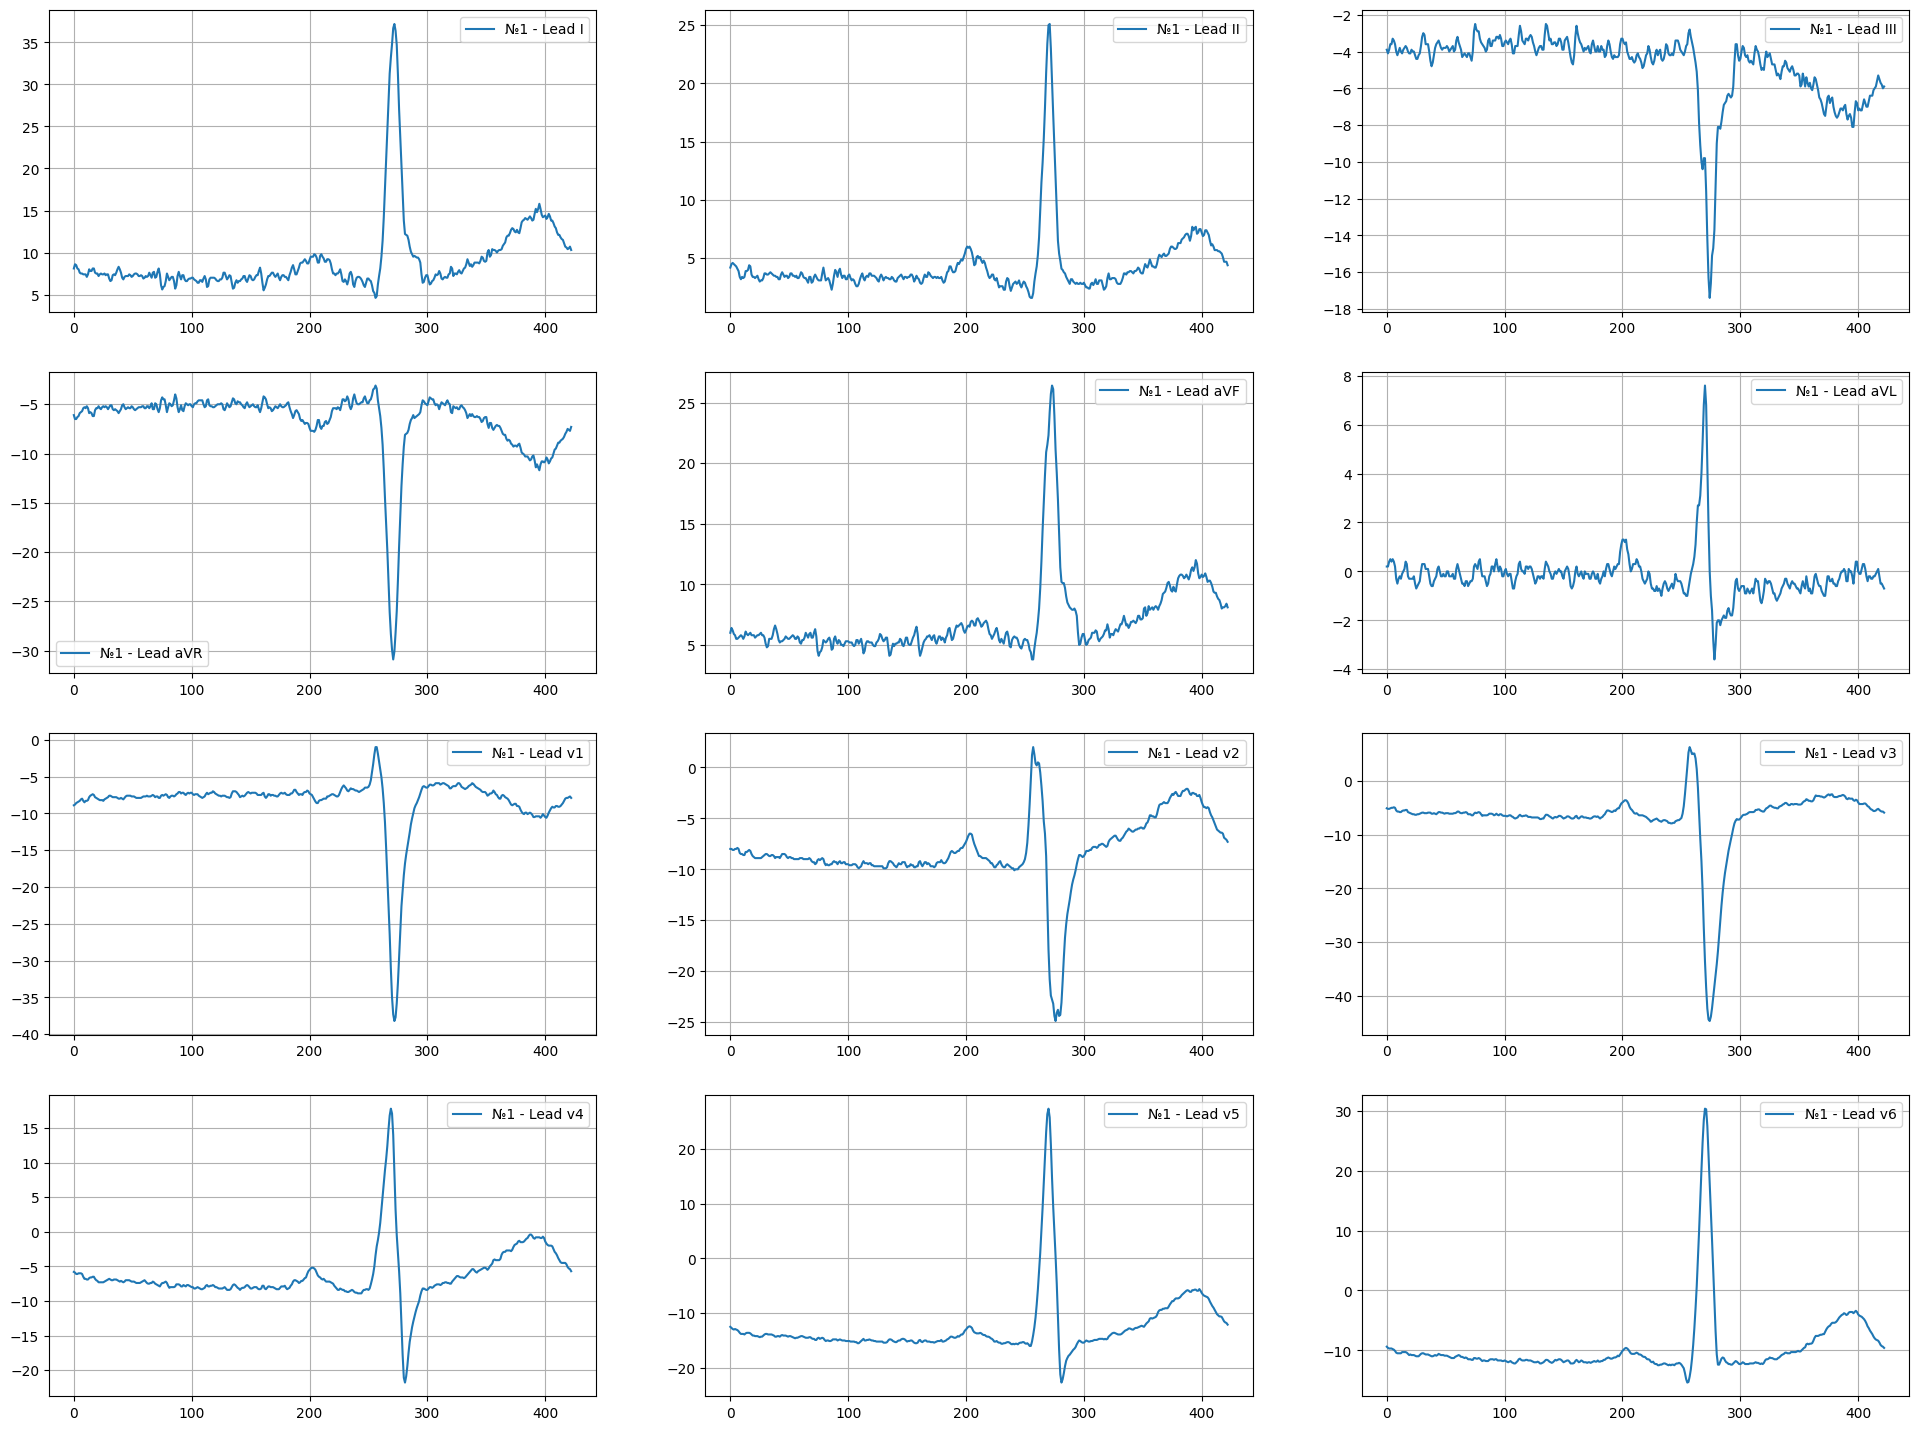

In [7]:
plt.figure(figsize=(24, 18))
dataset.visualize(1, 1)

### Обыкновенная депикизация

Как известно, весь датасет уже разделён на пики — что в принципе нам даже удобнее...

Но что, если нам для чего-то потребуется найти полные записи поцыэнта? К счастью, порядок записей после разделения на пики не был перемешан! Поэтому можно, проанализировав разрыв на краях каждого канала и выделив некоторый усреднённый порог, достаточно точно сказать, закончилась ли текущая запись или нет.

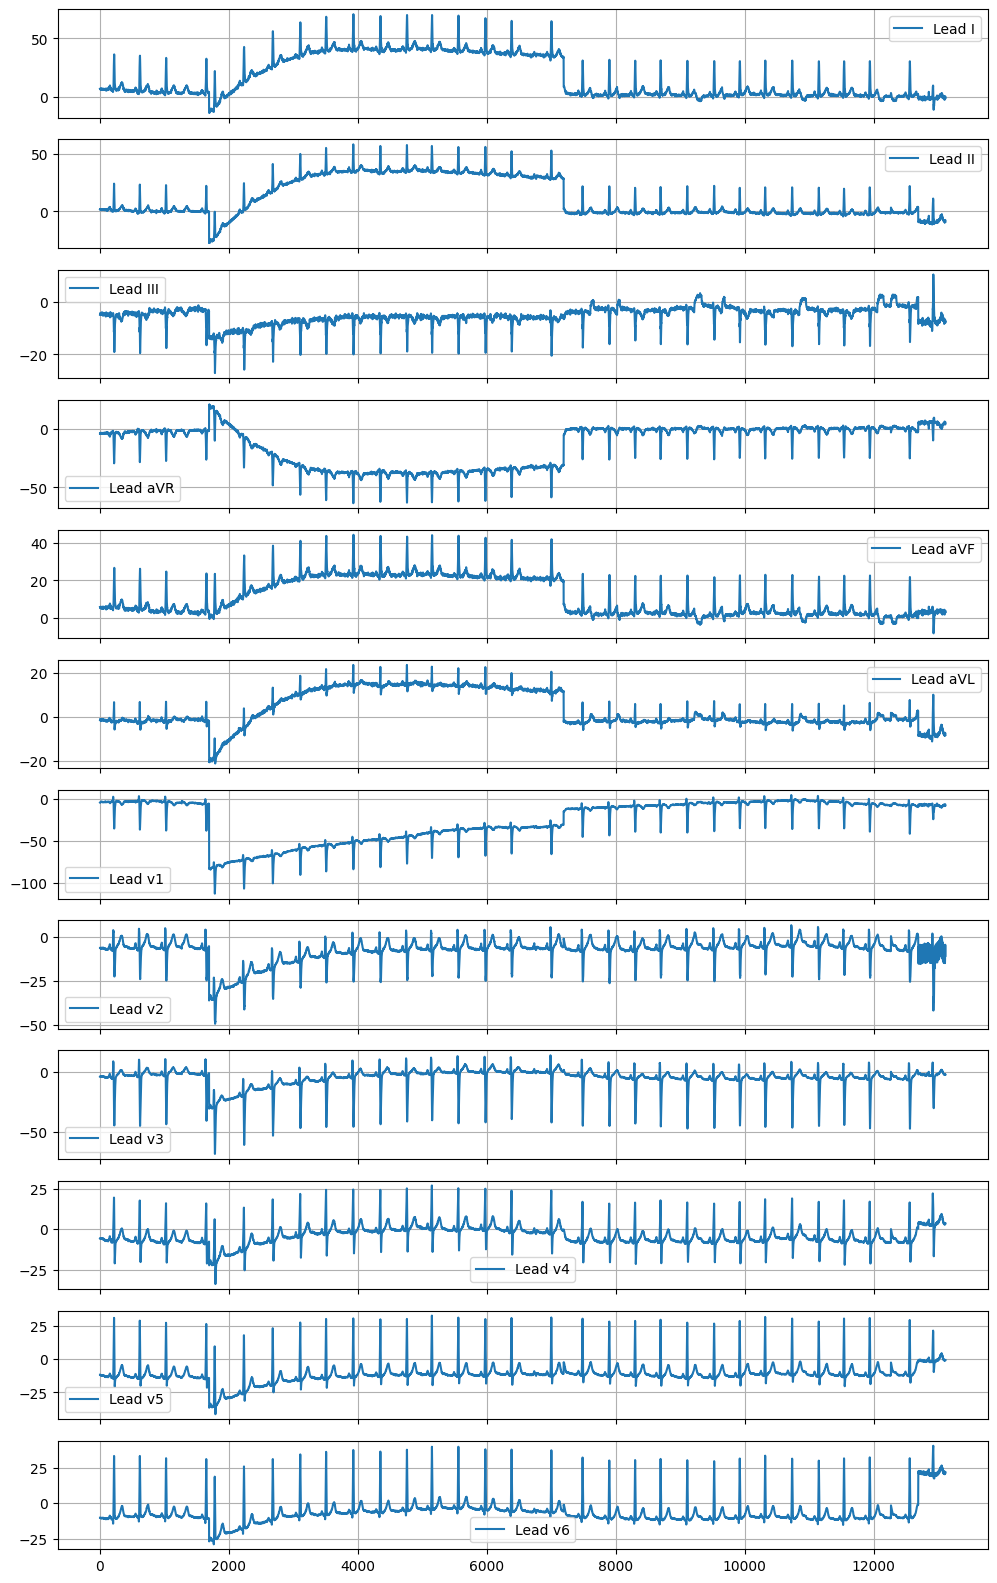

In [8]:
#Берём данные с 10 по 30 элемент
data_range_start = 10
data_range_step = 30
data_range = [dataset[i] for i in range(data_range_start, data_range_start+data_range_step+1)]

#Конкатим все отведения
data_range_concat = {
    ch: np.concatenate([sample[ch] for sample in data_range], axis=0) for ch in labels
}

fig, axes = plt.subplots(len(labels), 1, figsize=(12, 20), sharex=True)
time = np.arange(data_range_concat[labels[0]].shape[0])

for ax, ch in zip(axes, labels):
    ax.plot(time, data_range_concat[ch], label=ch)
    ax.legend()
    ax.grid()
# plt.xlim(400, 410)

plt.show()

Именно это мы сейчас и сделаем...

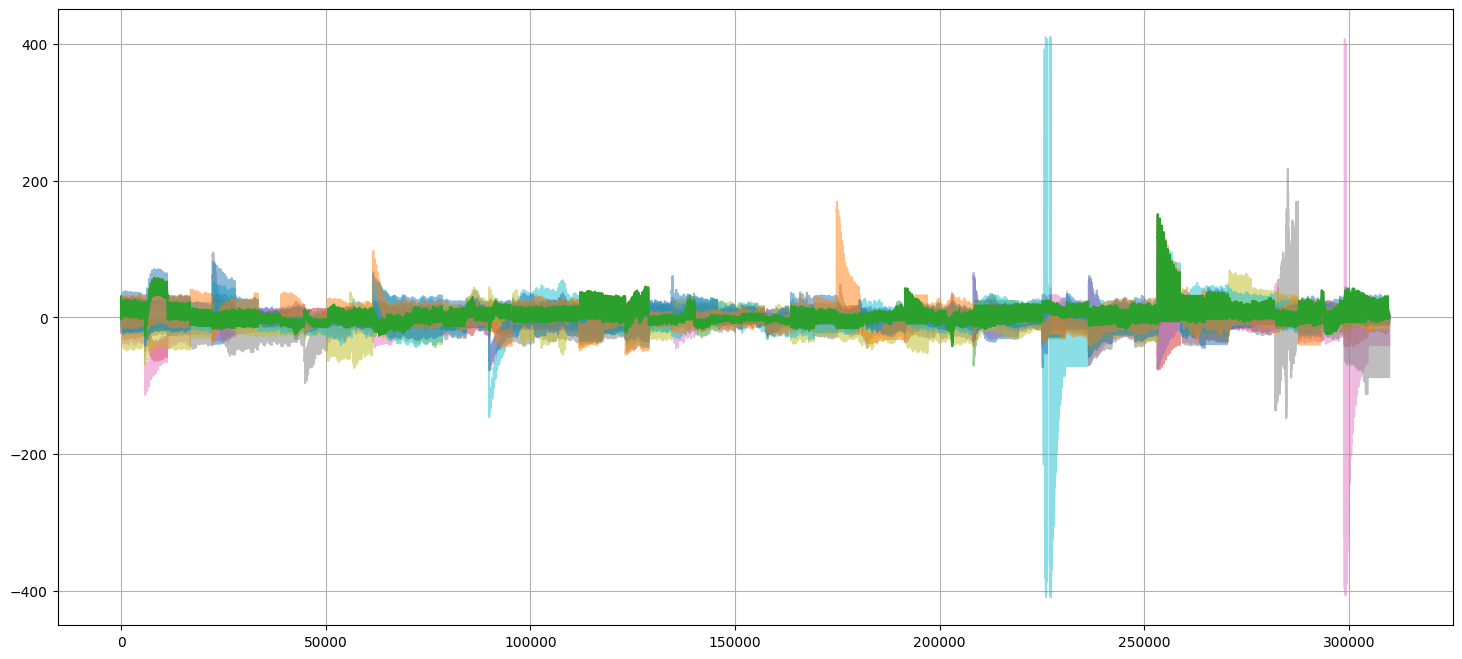

In [9]:
data = [dataset[i] for i in range(len(dataset))]

data_concat = {
    ch: np.concatenate([sample[ch] for sample in data], axis=0) for ch in labels
}


# господь_покинул_этот_мир.jpg
# ch_avg = np.sum(list([data_concat[ch] / len(labels) for ch in labels]), axis=0)

plt.figure(figsize=(18, 8))
for label in labels:
    plt.plot(data_concat[label], alpha=0.5)

plt.plot(data_concat['Lead II']) # Чаще всего для извлечения признаков ВСР берут этот канал

plt.grid()
plt.show()

Вейвлет Де Боша ~~(нет блин фильтр резни)~~ взят из preproc.ipynb

In [10]:
def denoise_ppg(ppg_signal, wavelet='db2', level=2, threshold_factor=1.5):
    coeffs = pywt.wavedec(ppg_signal, wavelet, level=level)

    sigma = np.median(np.abs(coeffs[-1])) / 0.6745
    threshold = threshold_factor * sigma

    coeffs_thresholded = [pywt.threshold(c, threshold, mode='soft') for c in coeffs]

    denoised_signal = pywt.waverec(coeffs_thresholded, wavelet)
    denoised_signal = denoised_signal[:len(ppg_signal)]

    return denoised_signal

data_filtered = [
    { label: denoise_ppg(data[i][label], 'db5', 10, 5) for label in labels }
    for i in range(len(dataset))
]

data_filtered_concat = {
    ch: np.concatenate([sample[ch] for sample in data_filtered], axis=0) for ch in labels
}


deltas_threshold = 3.0  

rec_slices = [
    slice(-9999, 0) # Временное значение, чтобы не было ошибки
]

for i in range(len(dataset) - 1):
    deltas_mean = 0

    for label in labels:
        delta = np.abs(
            np.median(np.abs(data_filtered[i][label])) - np.median(np.abs(data_filtered[i+1][label]))
            # data[i][label][-1] - data[i+1][label][0]
        )
        deltas_mean += delta / len(labels)
    print(f'Средняя дельта между №{i} и №{i+1} -- {deltas_mean}')

    if (deltas_mean > deltas_threshold) or (i == len(dataset) - 2):
        rec_slices.append(
            slice(rec_slices[-1].stop, i+2)
        )

rec_slices.pop(0) # Удаляем временное значение

print('\nПредположительные отрезки записей: ' + str(rec_slices))

Средняя дельта между №0 и №1 -- 4.381330069951121
Средняя дельта между №1 и №2 -- 0.7208319123738751
Средняя дельта между №2 и №3 -- 0.6577914100687895
Средняя дельта между №3 и №4 -- 0.4422269867486706
Средняя дельта между №4 и №5 -- 0.5315514887734564
Средняя дельта между №5 и №6 -- 0.3726928213205356
Средняя дельта между №6 и №7 -- 0.7658933980847333
Средняя дельта между №7 и №8 -- 0.3931183628565888
Средняя дельта между №8 и №9 -- 0.5536850460347486
Средняя дельта между №9 и №10 -- 0.46588542953188133
Средняя дельта между №10 и №11 -- 0.8863835304635244
Средняя дельта между №11 и №12 -- 0.6680795058644532
Средняя дельта между №12 и №13 -- 0.24312774208670124
Средняя дельта между №13 и №14 -- 16.131984369710757
Средняя дельта между №14 и №15 -- 7.567200821222008
Средняя дельта между №15 и №16 -- 6.43803261182404
Средняя дельта между №16 и №17 -- 4.407720110238149
Средняя дельта между №17 и №18 -- 2.156786162470245
Средняя дельта между №18 и №19 -- 1.305068067336246
Средняя дельта ме

Посмотрим, что получилось... нутакое

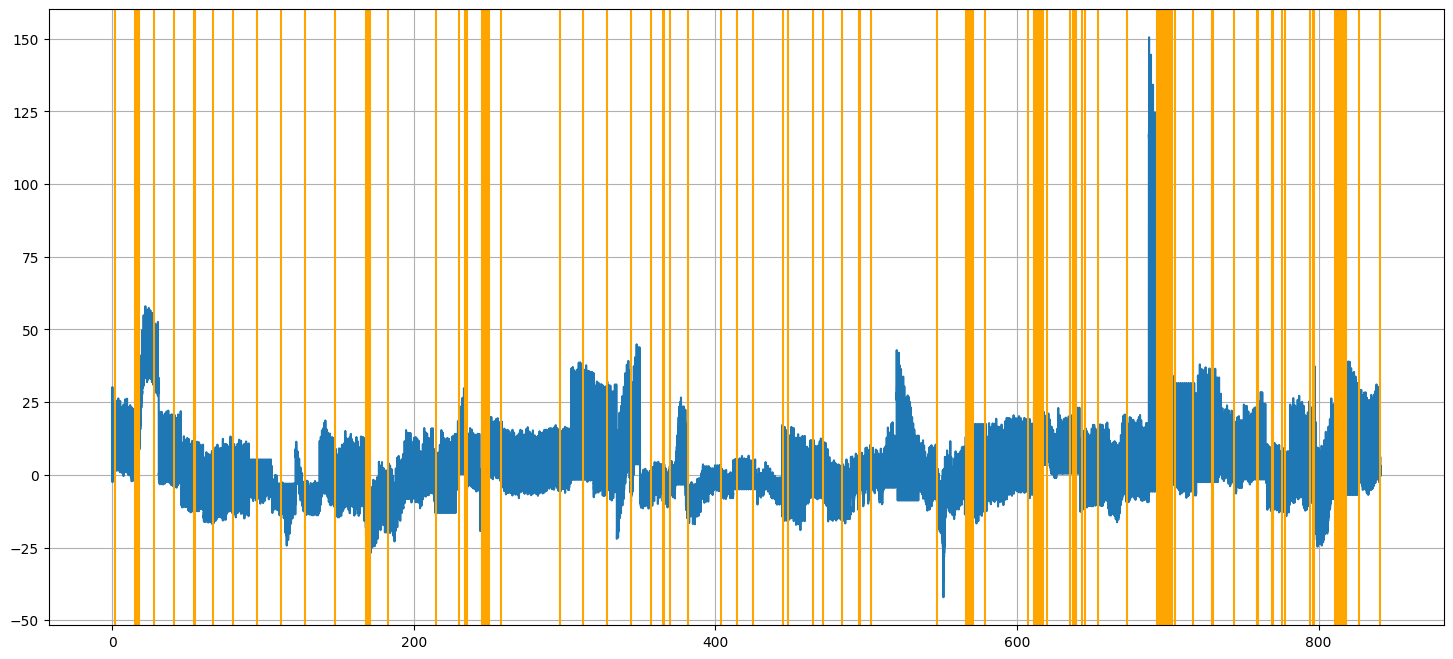

In [11]:
plt.figure(figsize=(18, 8))
plt.plot(np.arange(0, len(dataset), len(dataset) / len(data_concat['Lead II'])), data_concat['Lead II'])

for rs in rec_slices:
    plt.axvline(rs.stop, color='orange')

plt.grid()
plt.show()

В отчании я решил попробовать разбить сигналы константами, чтобы возможно увидеть какие-то взаимосвязи… и обаружил, что длины каждой из записей в полностью сконкатенированном датасете равны, просто имеют немноого разные смещение и длину в зависимости от типа расстройства!!

Абсолютно верного значения, конечно же, не существует, но для устранения всех погрешностей достаточно вырезать все те пики, на которые приходится разделение записи.

54.17754098360656


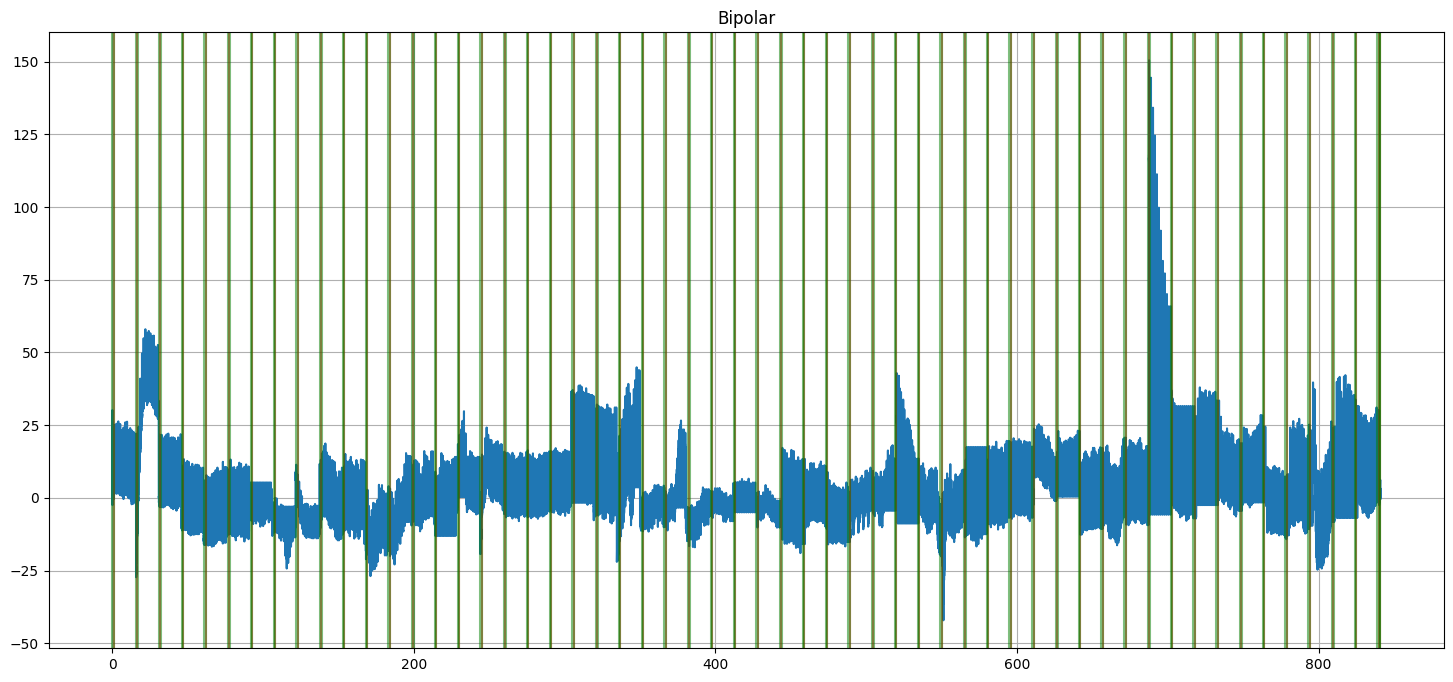

In [12]:
podbor = []


if dataset.pinned_disorder == 'Depression':
    print(len(dataset) / 14.49 - 0.79)
    podbor.append(0.79)
elif dataset.pinned_disorder == 'Schizophrenia':
    print(len(dataset) / 14.263 - 12.461)
    podbor.append(12.461)
elif dataset.pinned_disorder == 'Bipolar':
    print(len(dataset) / 15.25 - 0.97)
    podbor.append(0.97)

while podbor[-1] < len(dataset):
    if dataset.pinned_disorder == 'Depression':
        podbor.append(podbor[-1] + 14.45)
    elif dataset.pinned_disorder == 'Schizophrenia':
        podbor.append(podbor[-1] + 14.263)
    elif dataset.pinned_disorder == 'Bipolar':
        podbor.append(podbor[-1] + 15.25)

# Исправляем последний пик, чтобы в slice он лежал ровно на конце данных
podbor[-1] = float(np.floor(len(dataset)))


plt.figure(figsize=(18, 8))
plt.plot(np.arange(0, len(dataset), len(dataset) / len(data_concat['Lead II'])), data_concat['Lead II'])
for abobus in podbor:
    plt.axvline(abobus, color='red', alpha=0.5)
    plt.axvline(np.ceil(abobus), color='green', alpha=0.5)
    plt.axvline(np.floor(abobus), color='green', alpha=0.5)

# plt.xlim(0, 20)
plt.title(dataset.pinned_disorder)
plt.grid()
plt.show()

### Наконец, скормим наши данные в HeartPy

На это момент мой мозг потихоньку нчал плавиться, потому код тоже деградировать малясь)))

In [13]:
fs = 416 # 500? 416?? 256???

In [14]:
# b, a = butter_bandpass(0.5, 10, fs)
# filtered_signal = filtfilt(b, a, ppg_example_finger)

# wd, m = hp.process(
#     filtered_signal,
#     sample_rate=fs
# )

# hp.plotter(wd, m)
# plt.show()

# for measure in m.keys():
#     print('%s: %f' %(measure, m[measure]))

In [15]:
data_slices = [slice(
        int(np.ceil(podbor[i]) / len(dataset) * len(data_concat['Lead II']) + fs//2),
        int(np.floor(podbor[i+1]) / len(dataset) * len(data_concat['Lead II']) - fs//2)
    ) for i in range(1, len(podbor)-1)
]

print('\nОтрезки записей в данных (с обрезанными концами): ' + str(data_slices))


Отрезки записей в данных (с обрезанными концами): [slice(6471, 11212, None), slice(11997, 16739, None), slice(17523, 22265, None), slice(23049, 28159, None), slice(28944, 33686, None), slice(34470, 39212, None), slice(39996, 44738, None), slice(45522, 50633, None), slice(51417, 56159, None), slice(56943, 61685, None), slice(62469, 67211, None), slice(67996, 73106, None), slice(73890, 78632, None), slice(79416, 84158, None), slice(84943, 89684, None), slice(90469, 95579, None), slice(96364, 101105, None), slice(101890, 106632, None), slice(107416, 112158, None), slice(112942, 118052, None), slice(118837, 123579, None), slice(124363, 129105, None), slice(129889, 134631, None), slice(135415, 140526, None), slice(141310, 146052, None), slice(146836, 151578, None), slice(152362, 157104, None), slice(157889, 162999, None), slice(163783, 168525, None), slice(169309, 174051, None), slice(174836, 179577, None), slice(180362, 185472, None), slice(186256, 190998, None), slice(191783, 196524, Non

In [16]:
i = 0

data = {
    'bpm': [],
    'sdnn': [],
    'rmssd': [],
    'hr_mad': [],
    'lf': [],
    'hf': [],
    'lf/hf': [],
    'rsa': []
}
r_peaks = []

def butter_bandpass_filter(data, lowcut, highcut, sample_rate, order=4):
        nyq = 0.5 * sample_rate
        low = lowcut / nyq
        high = highcut / nyq
        b, a = butter(order, [low, high], btype='band')
        return filtfilt(b, a, data)

print(len(data_slices))

55


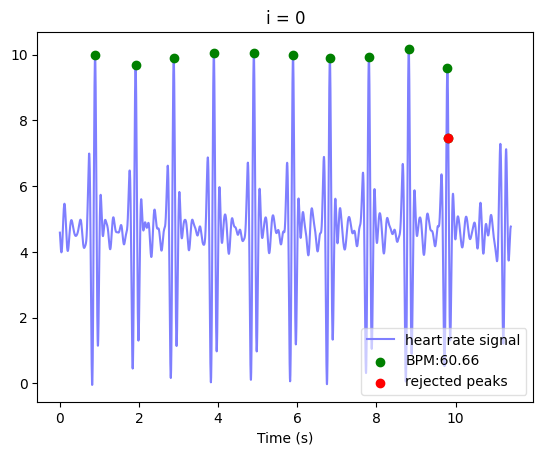

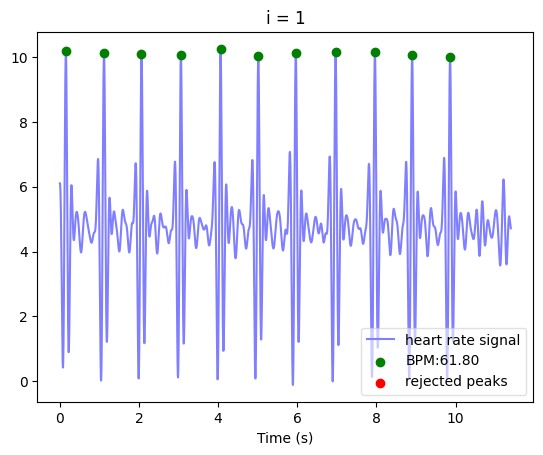

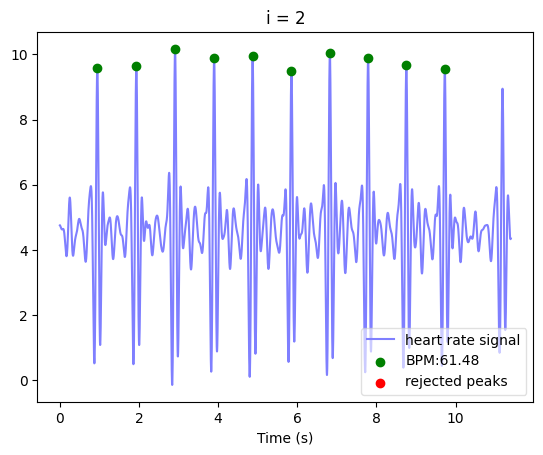

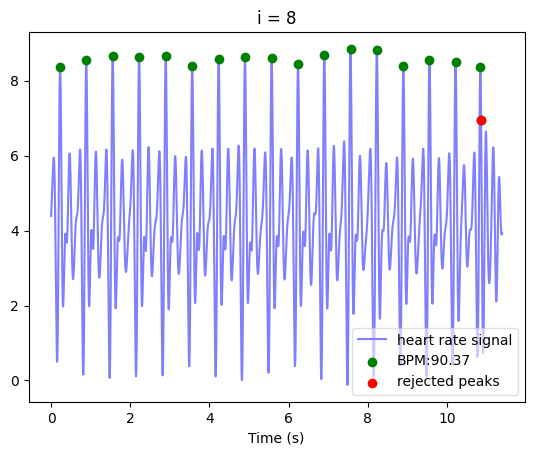

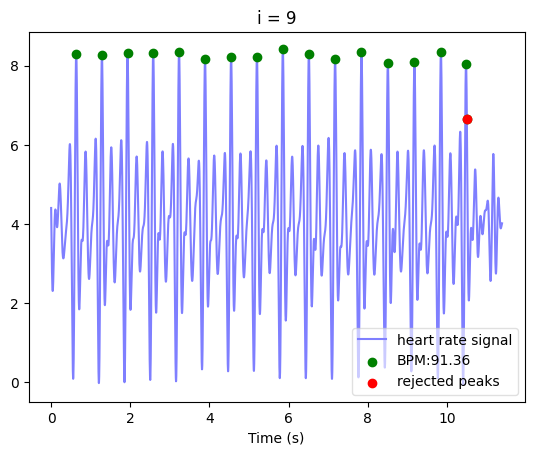

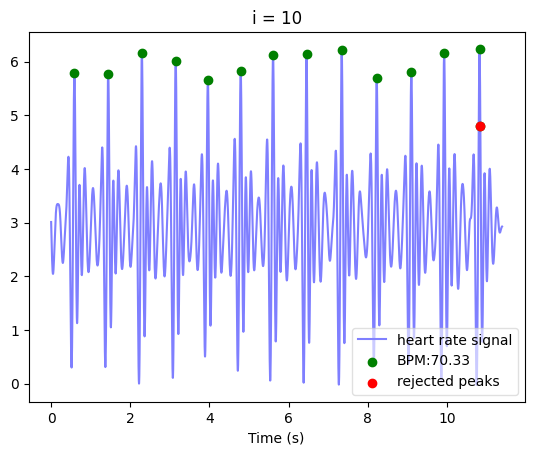

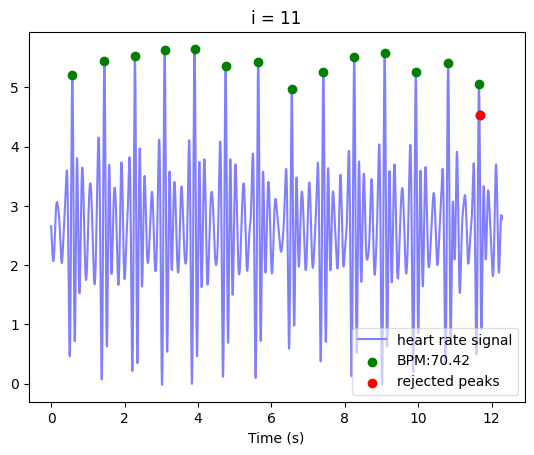

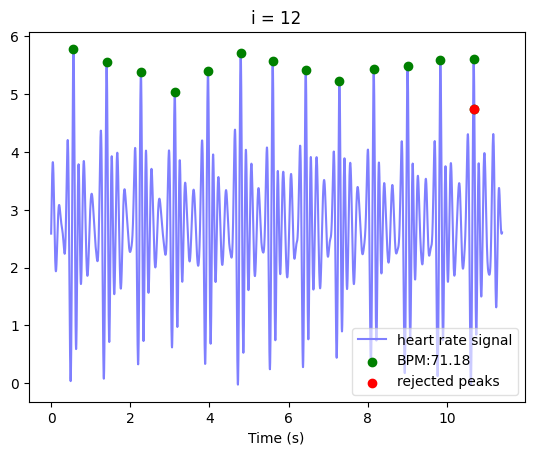

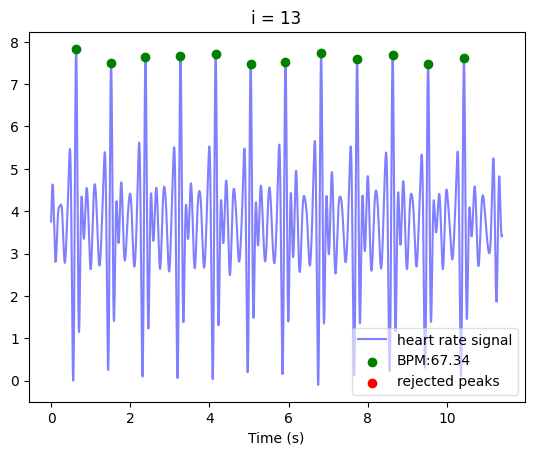

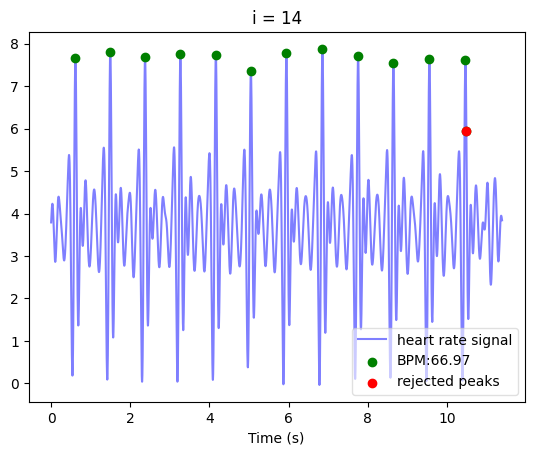

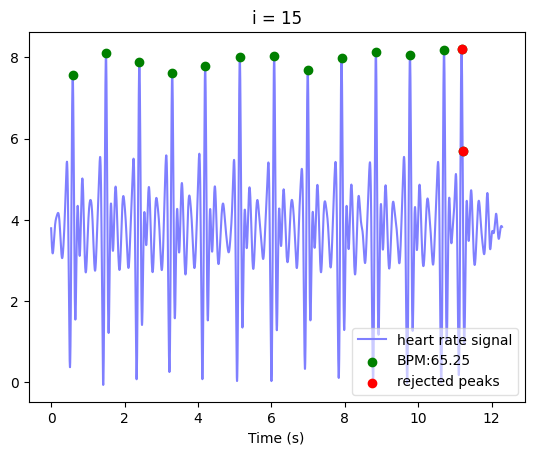

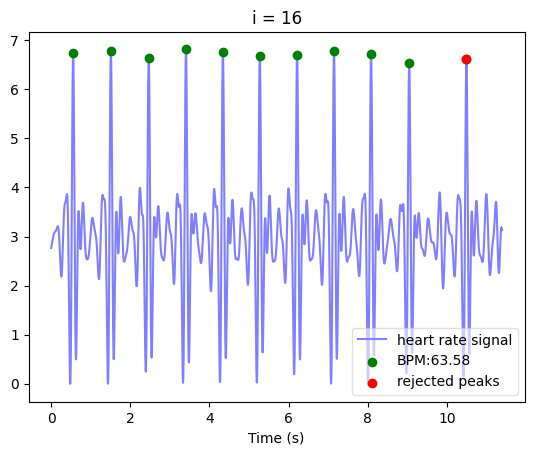

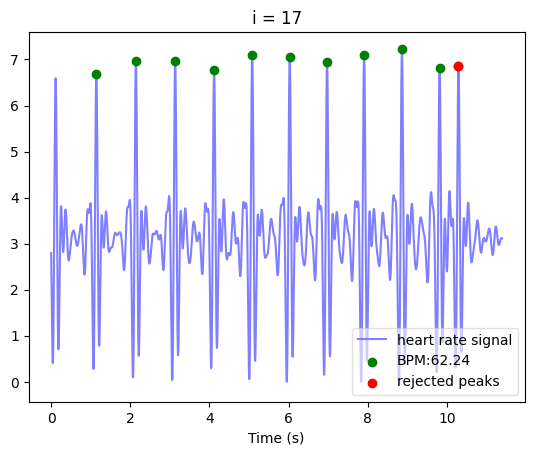

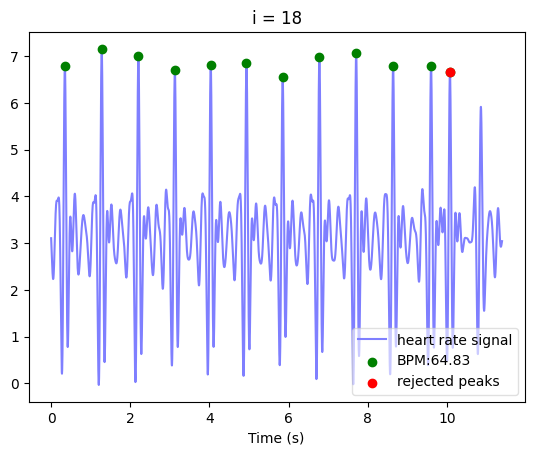

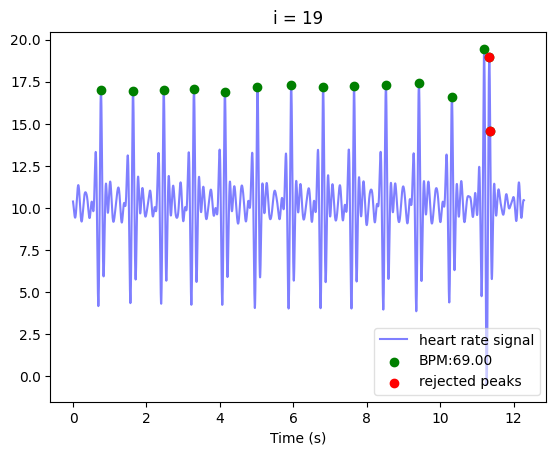

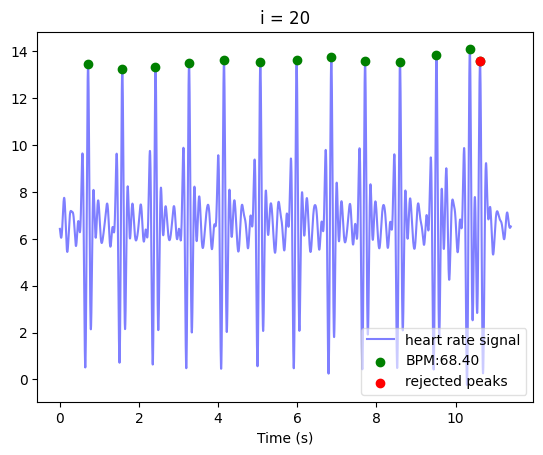

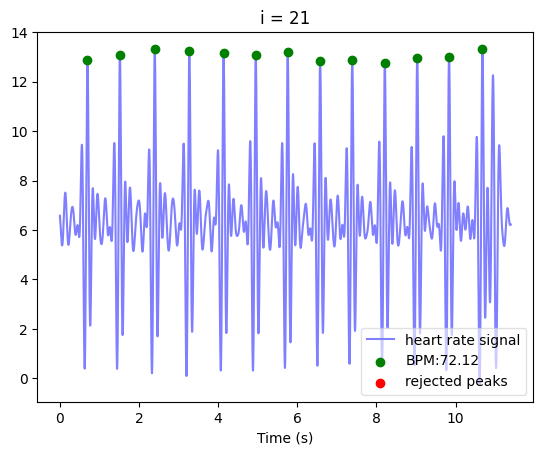

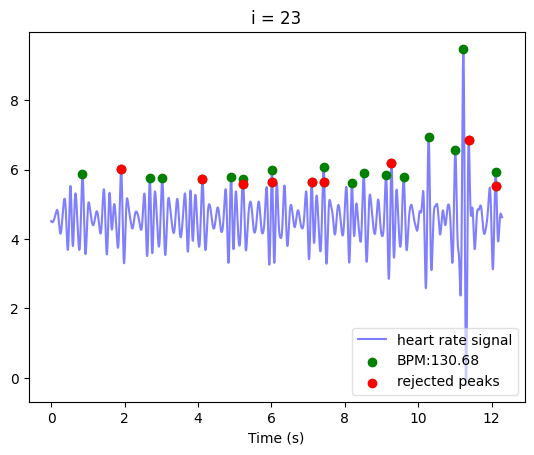

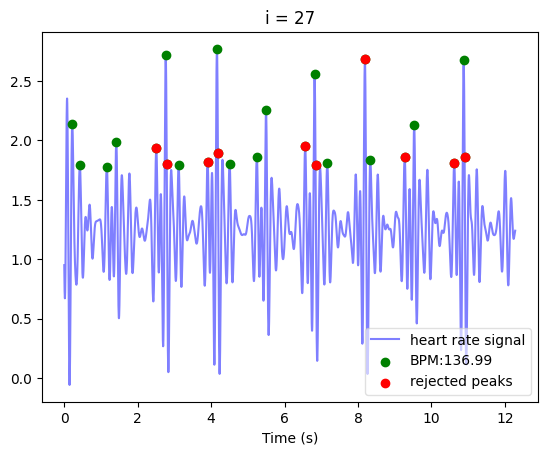

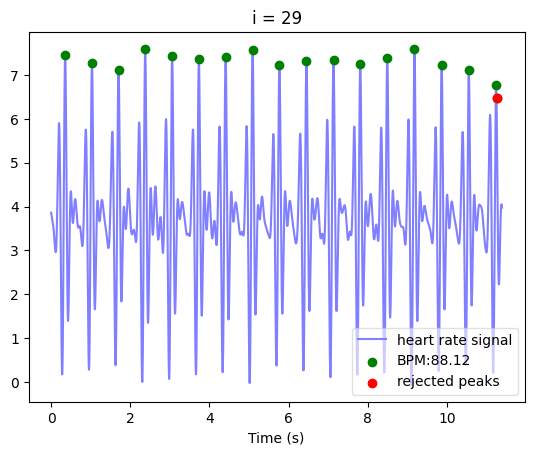

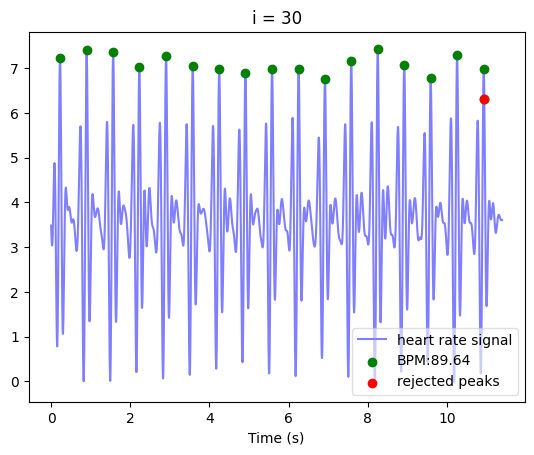

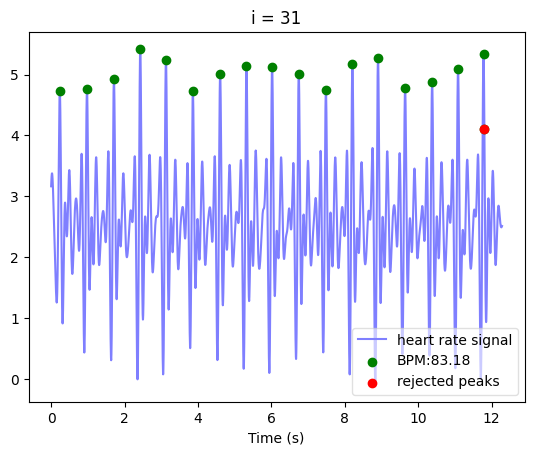

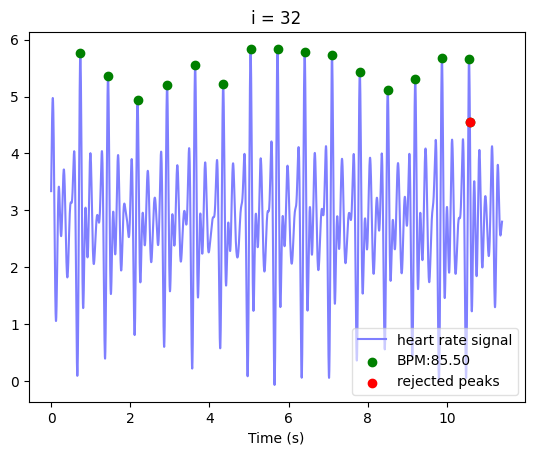

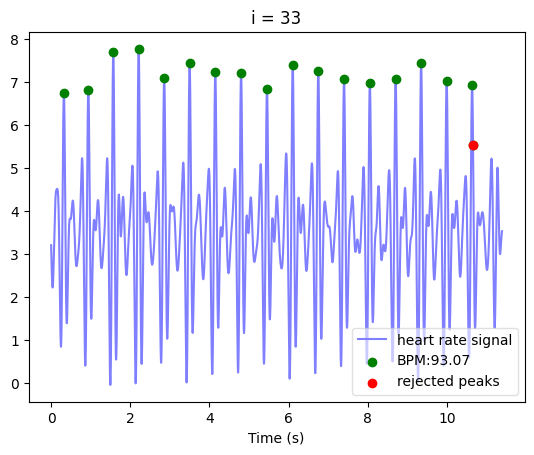

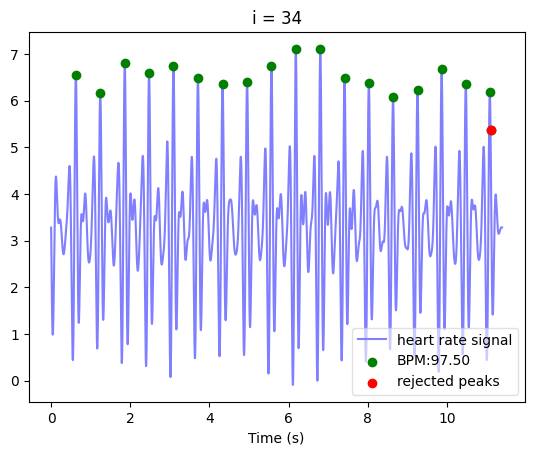

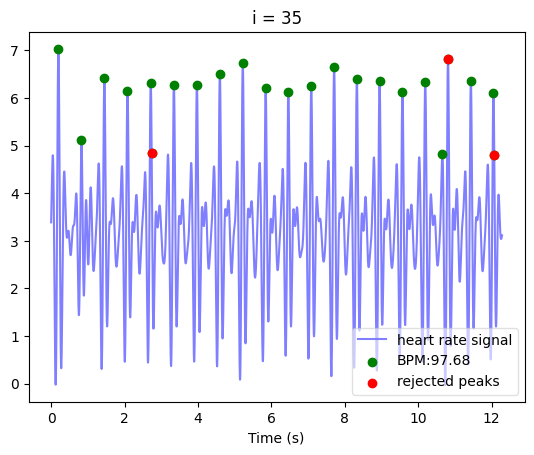

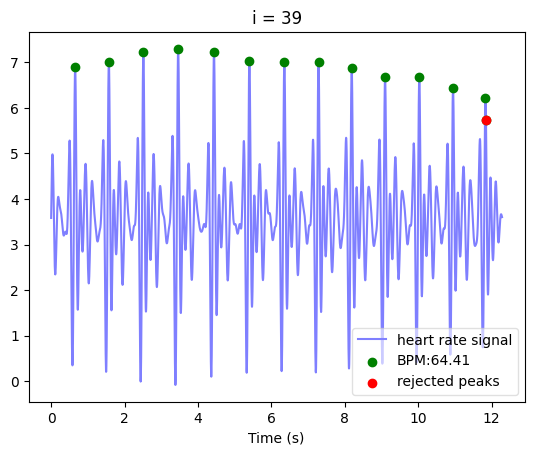

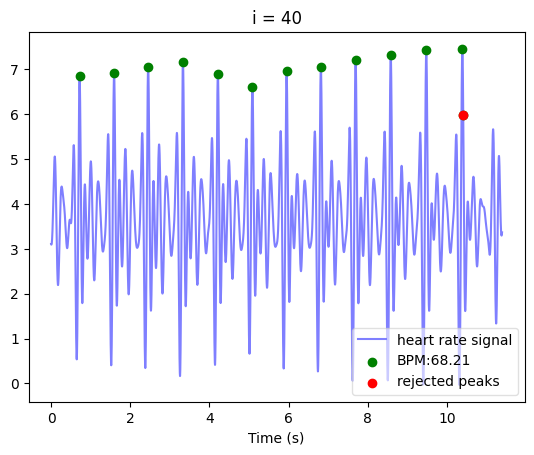

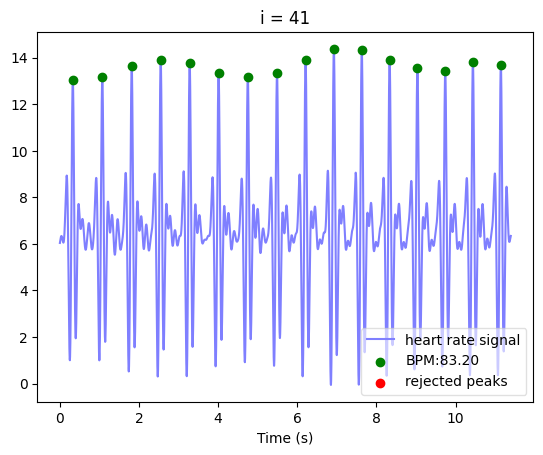

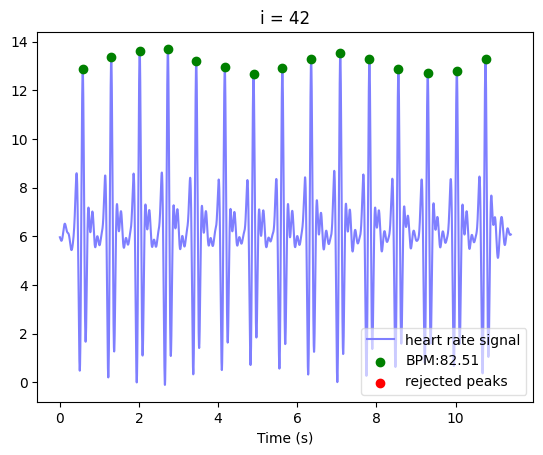

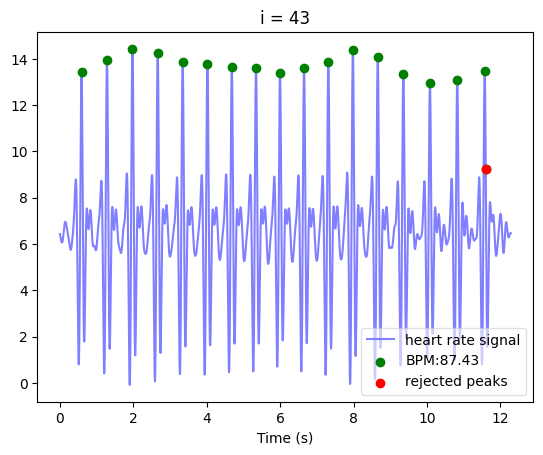

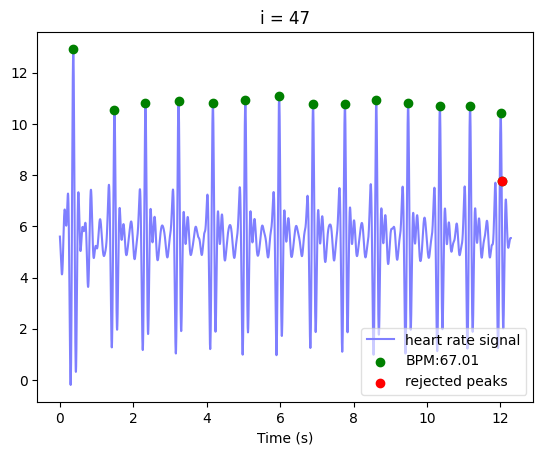

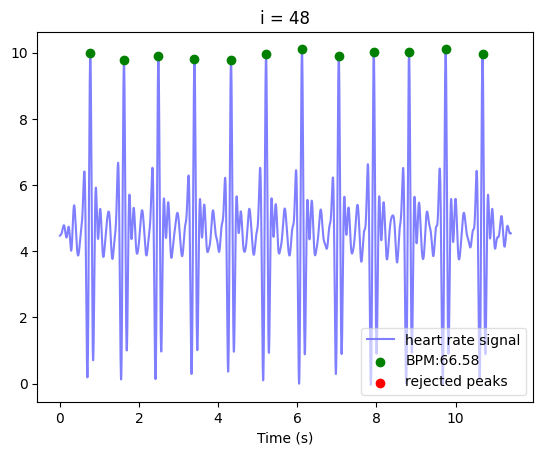

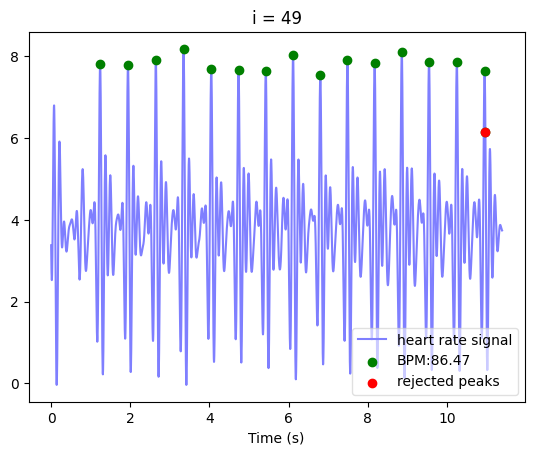

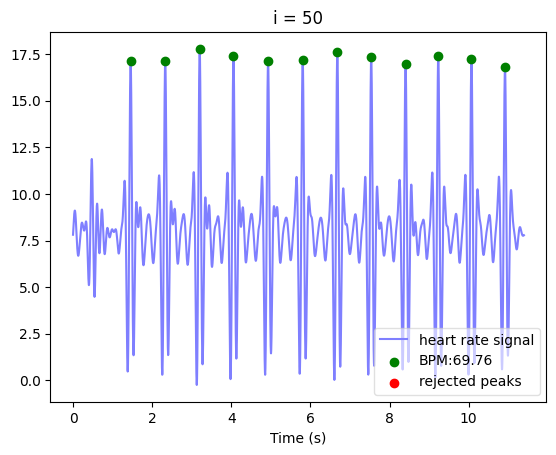

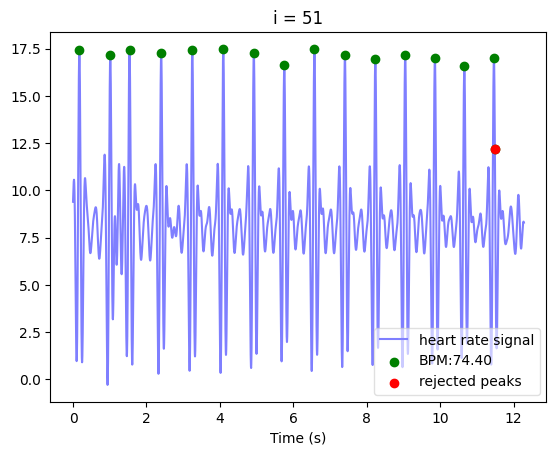

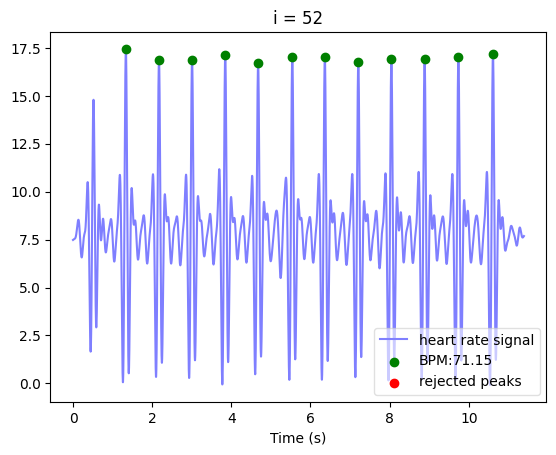

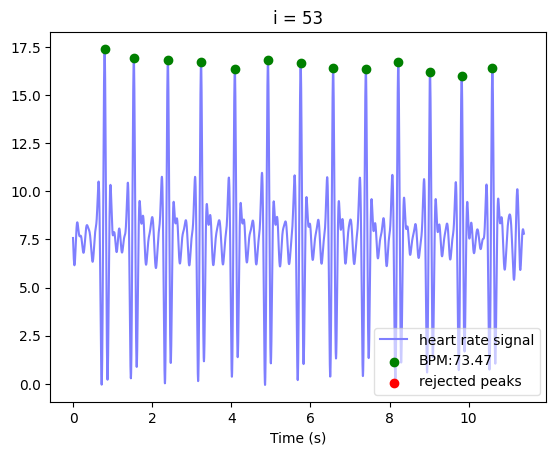

In [17]:
for slc in data_slices:
    raised = True
    while raised:
        try:
            wd, m = hp.process(
                butter_bandpass_filter(data_filtered_concat['Lead II'][slc], 4, 9, fs),
                sample_rate=fs
            )

            if ((not np.isnan(m['bpm'])) and (m['bpm'] < 140.0) and (m['bpm'] > 60.0)):
                # print(m, wd)
                data['bpm'].append(m['bpm'])
                data['sdnn'].append(m['sdnn'])
                data['rmssd'].append(m['rmssd'])
                data['hr_mad'].append(m['hr_mad'])

                r_peaks.append(wd['RR_list'])

                # data['rri'].append(
                #     np.asarray(wd['RR_list']) / fs
                # )
                
                hp.plotter(wd, m)
                plt.title(f'i = {i}')
                plt.show()

            raised = False
            i += 1

        except BaseException:
            if slc.stop - slc.start < fs:
                raised = False
                continue
            slc = slice(slc.start, slc.stop-100)


# peaks, _ = find_peaks(wd['hr'])

# print(wd.keys())
# print(wd['hr'], wd['sample_rate'])

# hp.plotter(wd, m)
# plt.scatter(peaks/fs, wd['hr'][peaks])
# plt.show()

# for measure in m.keys():
#     print('%s: %f' %(measure, m[measure]))

In [18]:
print(len(data['rmssd']))

38


Данные HRV с гойрем пополам вытащили... хотя как видно и не без потерь...

Теперь будем из них вытаскивать LF/HF, благо здесь мы можем заюзать наш уже готовый препроцессор...

_Юджин дорогой!!! Привет от детей Луганска 🔫👧🏻_

In [19]:
import sys
import os
sys.path.append(os.path.abspath("../PPG-Mental-Evaluation"))
from dataproc.preprocess import PreprocessPPG

In [20]:
p = PreprocessPPG()

for rp in r_peaks:
    # rp_expanded = []
    # while len(rp_expanded) < 30:
    #     rp_expanded = [*rp_expanded, *rp]

    # Сохрнаять LF и HF/LF нет смысла, т.к. LF определился 100% некорректно... но можем взять HF
    lf_hf = p.find_lf_hf(rp)
    print(lf_hf)
    data['lf'].append(lf_hf['lf'])
    data['hf'].append(lf_hf['hf'])
    data['lf/hf'].append(lf_hf['lf/hf'])

    # А из HF, по коряво приближённой формуле, можно вычислить и RSA! Неплохо? Я считаю неплохо.
    rsa = p.find_rsa(None, None, None, lf_hf['hf'])
    print(rsa)
    data['rsa'].append(rsa)

{'lf': np.float64(6.518849484638773), 'hf': np.float64(1.8297489081238547), 'lf/hf': np.float64(3.5627016667127944)}
0.6041787487638689
{'lf': np.float64(0.2928998600427418), 'hf': np.float64(0.23477312033529382), 'lf/hf': np.float64(1.247586860133024)}
-1.4491356765622754
{'lf': np.float64(0.1624217772732773), 'hf': np.float64(0.1126221110126057), 'lf/hf': np.float64(1.4421837400570263)}
-2.1837172147690462
{'lf': np.float64(3.3667245200756994), 'hf': np.float64(1.3832588211239656), 'lf/hf': np.float64(2.4339078621165564)}
0.32444217987603086
{'lf': np.float64(9.133548319469057), 'hf': np.float64(2.4003565665771527), 'lf/hf': np.float64(3.805079814659896)}
0.8756172957257055
{'lf': np.float64(2.72448997211419), 'hf': np.float64(1.070823981083797), 'lf/hf': np.float64(2.544293011963267)}
0.06842842789684614
{'lf': np.float64(8.019032932372662), 'hf': np.float64(2.307570157551348), 'lf/hf': np.float64(3.4750982136473665)}
0.8361950910719361
{'lf': np.float64(10.8503952946352), 'hf': np.

Ну и хватит с нас — или с вас ;) — данных... нацедим их в цсв файлик 🍼

In [21]:
data

{'bpm': [np.float64(60.66432622198217),
  np.float64(61.797474622431295),
  np.float64(61.477832512315274),
  np.float64(90.37338764426342),
  np.float64(91.36163982430455),
  np.float64(70.32636769194647),
  np.float64(70.41666666666667),
  np.float64(71.17870722433459),
  np.float64(67.34363502575422),
  np.float64(66.96585365853659),
  np.float64(65.24714828897339),
  np.float64(63.58335692046418),
  np.float64(62.24438902743143),
  np.float64(64.83116883116882),
  np.float64(68.99792674498964),
  np.float64(68.40059790732437),
  np.float64(72.1213580544185),
  np.float64(130.6806282722513),
  np.float64(136.99231613611417),
  np.float64(88.12003530450133),
  np.float64(89.64309764309766),
  np.float64(83.18267027702564),
  np.float64(85.50036701737216),
  np.float64(93.06921463528313),
  np.float64(97.5),
  np.float64(97.67955801104974),
  np.float64(64.41290322580645),
  np.float64(68.21366459627329),
  np.float64(83.2),
  np.float64(82.51239669421487),
  np.float64(87.42556917688

In [22]:
import pandas as pd

data_pd = pd.DataFrame(data)
data_pd.to_csv(f"Psychiatry-ECG__{dataset.pinned_disorder}-{fs}.csv", index=False)

# **ВОТ И ВСЁ.**